Q1. Write a Python program to implement and plot both NRZ-L and NRZ-I line encoding.

Your program should:

Accept the given bit stream as input. [2 marks]

Implement NRZ-L encoding. [5 marks]

Implement NRZ-I encoding. [5 marks]

Plot the original bit stream and the two encoded signals using Matplotlib. [5 marks]

Clearly label the axes, bit boundaries, and signal levels. [3 marks]

Given the bit stream:

10110010

Bit Stream : 10110010
NRZ-L      : [-1, 1, -1, -1, 1, 1, -1, 1]
NRZ-I      : [-1, -1, 1, -1, -1, -1, 1, 1]


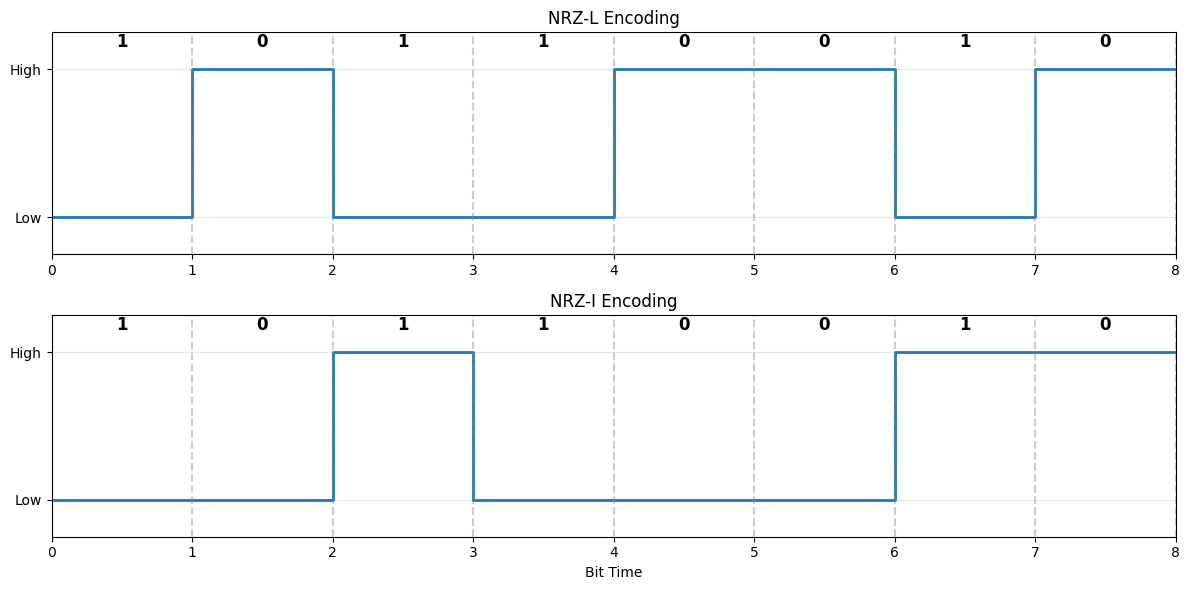

In [1]:
import matplotlib.pyplot as plt

# Given bit stream
bits = "10110010"

# -------------------------------------------------
# NRZ-L Encoding
# Convention:
# 0 -> +1
# 1 -> -1
# -------------------------------------------------

def nrz_l(bits):
    signal = []

    for bit in bits:
        if bit == '0':
            signal.append(1)
        else:
            signal.append(-1)

    return signal


# -------------------------------------------------
# NRZ-I Encoding
# Convention:
# 1 -> transition at beginning of bit
# 0 -> no transition
# Initial level = +1
# -------------------------------------------------

def nrz_i(bits):
    signal = []
    level = 1

    for bit in bits:

        if bit == '1':
            level = -level

        signal.append(level)

    return signal


# Generate signals
nrz_l_signal = nrz_l(bits)
nrz_i_signal = nrz_i(bits)

print("Bit Stream :", bits)
print("NRZ-L      :", nrz_l_signal)
print("NRZ-I      :", nrz_i_signal)


# -------------------------------------------------
# Plotting function
# -------------------------------------------------

def plot_signal(ax, signal, title):

    # Create time points
    t = []

    for i in range(len(signal)):
        t.extend([i, i + 1])

    y = []

    for value in signal:
        y.extend([value, value])

    ax.plot(
        t,
        y,
        drawstyle='steps-post',
        linewidth=2
    )

    # Bit boundaries
    for i in range(len(bits) + 1):
        ax.axvline(i, color='gray', linestyle='--', alpha=0.4)

    # Bit labels
    for i, bit in enumerate(bits):
        ax.text(
            i + 0.5,
            1.3,
            bit,
            ha='center',
            fontsize=12,
            fontweight='bold'
        )

    ax.set_title(title)
    ax.set_xlim(0, len(bits))
    ax.set_ylim(-1.5, 1.5)
    ax.set_yticks([-1, 1])
    ax.set_yticklabels(["Low", "High"])
    ax.grid(axis='y', alpha=0.3)


# -------------------------------------------------
# Create plots
# -------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

plot_signal(
    axes[0],
    nrz_l_signal,
    "NRZ-L Encoding"
)

plot_signal(
    axes[1],
    nrz_i_signal,
    "NRZ-I Encoding"
)

axes[1].set_xlabel("Bit Time")

plt.tight_layout()
plt.show()


Q2. Write a Python program to implement Manchester encoding.

Your program should:

Take the given bit stream as input. [2 marks]

Encode each bit using Manchester encoding. [6 marks]

Use two signal levels, +1 and -1. [3 marks]

Plot the original bit stream and Manchester encoded signal. [5 marks]

Mark the bit boundaries and explain the transition occurring in the middle of every bit. [4 marks]

Given the bit stream:

10110010

Bit Stream:
10110010

Manchester Signal:
[-1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, -1]


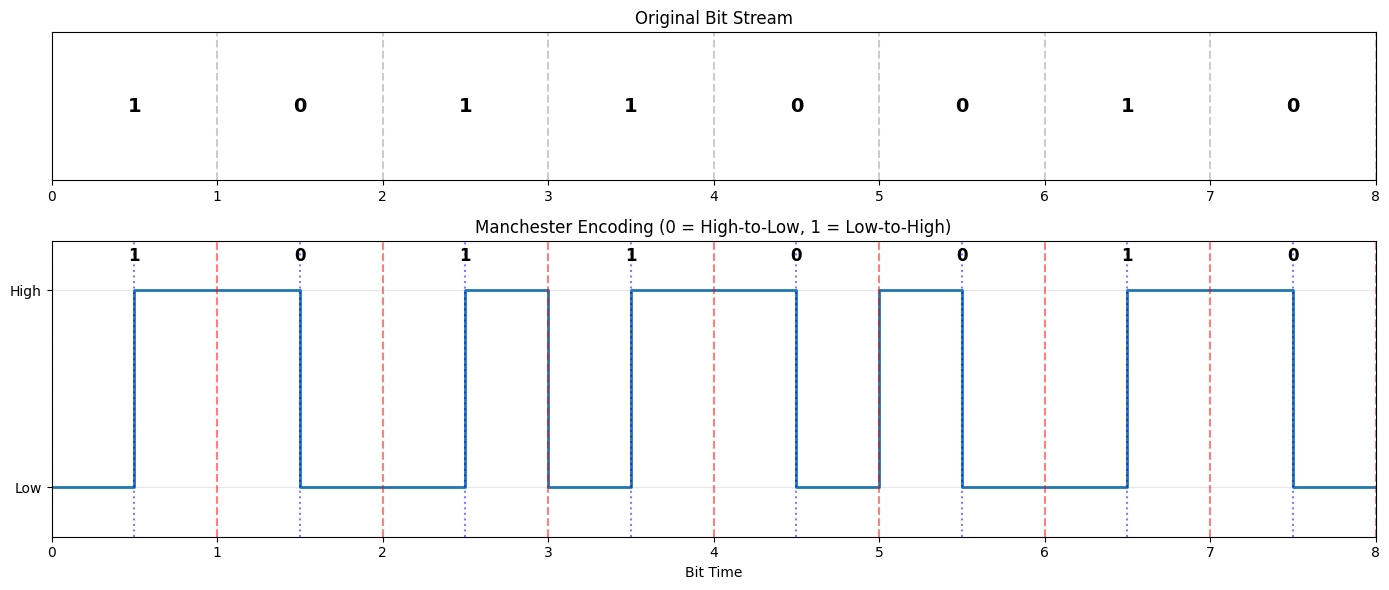

In [2]:
import matplotlib.pyplot as plt

# Given bit stream
bits = "10110010"


# -------------------------------------------------
# Manchester Encoding
#
# Convention:
# 0 -> High to Low
# 1 -> Low to High
# -------------------------------------------------

def manchester(bits):

    signal = []

    for bit in bits:

        if bit == '0':
            signal.extend([1, -1])

        else:
            signal.extend([-1, 1])

    return signal


# Generate Manchester signal
signal = manchester(bits)

print("Bit Stream:")
print(bits)

print("\nManchester Signal:")
print(signal)


# -------------------------------------------------
# Plot Manchester signal
# -------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 6),
    gridspec_kw={'height_ratios': [1, 2]}
)


# -------------------------------------------------
# Plot original bits
# -------------------------------------------------

axes[0].set_xlim(0, len(bits))
axes[0].set_ylim(-1, 1)

for i, bit in enumerate(bits):

    axes[0].text(
        i + 0.5,
        0,
        bit,
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

    axes[0].axvline(
        i,
        color='gray',
        linestyle='--',
        alpha=0.4
    )

axes[0].axvline(
    len(bits),
    color='gray',
    linestyle='--',
    alpha=0.4
)

axes[0].set_yticks([])
axes[0].set_title("Original Bit Stream")


# -------------------------------------------------
# Plot Manchester
# -------------------------------------------------

# Each bit occupies two half-bit intervals
t = []

for i in range(len(signal)):
    t.extend([i / 2, (i + 1) / 2])

y = []

for value in signal:
    y.extend([value, value])


axes[1].plot(
    t,
    y,
    drawstyle='steps-post',
    linewidth=2
)


# Bit boundaries
for i in range(len(bits) + 1):

    axes[1].axvline(
        i,
        color='red',
        linestyle='--',
        alpha=0.5
    )


# Middle-of-bit transitions
for i in range(len(bits)):

    axes[1].axvline(
        i + 0.5,
        color='blue',
        linestyle=':',
        alpha=0.5
    )


# Bit labels
for i, bit in enumerate(bits):

    axes[1].text(
        i + 0.5,
        1.3,
        bit,
        ha='center',
        fontsize=12,
        fontweight='bold'
    )


axes[1].set_xlim(0, len(bits))
axes[1].set_ylim(-1.5, 1.5)

axes[1].set_yticks([-1, 1])
axes[1].set_yticklabels(["Low", "High"])

axes[1].set_xlabel("Bit Time")
axes[1].set_title(
    "Manchester Encoding (0 = High-to-Low, 1 = Low-to-High)"
)

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Q3. Write a Python program to implement and plot Differential Manchester encoding.

Use the following convention:

0 → transition at the beginning of the bit

1 → no transition at the beginning

There is always a transition in the middle of every bit.

Initial signal level = High

Your program should:

Accept the bit stream. [2 marks]

Implement Differential Manchester encoding according to the given rules. [7 marks]

Display the encoded signal values. [3 marks]

Plot the original bits and encoded waveform. [5 marks]

Explain the difference between Manchester and Differential Manchester. [3 marks]

# Given bit stream
bits = "10110010"

Bit Stream:
10110010

Differential Manchester Signal:
[1, -1, 1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, 1, -1, 1]


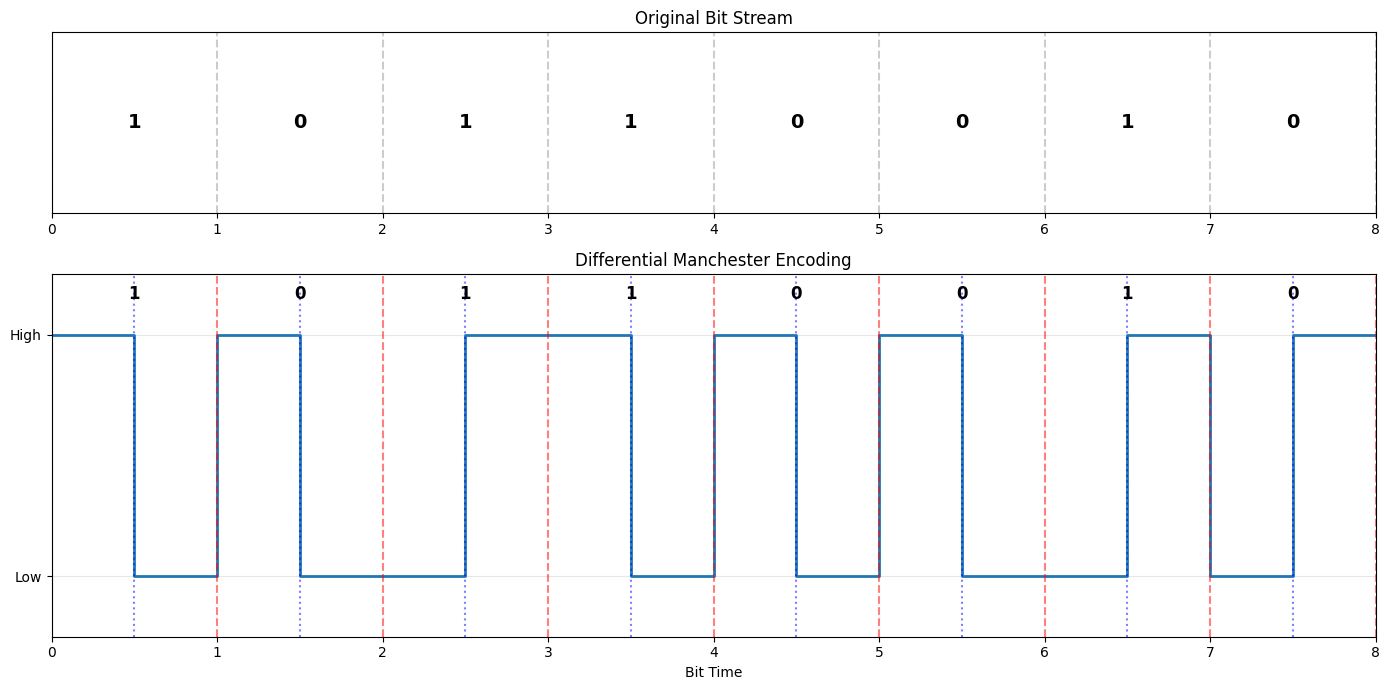

In [3]:
import matplotlib.pyplot as plt

# Given bit stream
bits = "10110010"


# -------------------------------------------------
# Differential Manchester Encoding
#
# Convention:
# 0 -> transition at beginning
# 1 -> no transition at beginning
#
# Always transition in the middle
#
# Initial level = High (+1)
# -------------------------------------------------

def differential_manchester(bits):

    signal = []

    level = 1

    for bit in bits:

        # Beginning-of-bit transition for 0
        if bit == '0':
            level = -level

        # First half of bit
        signal.append(level)

        # Mandatory middle transition
        level = -level

        # Second half of bit
        signal.append(level)

    return signal


# Generate signal
signal = differential_manchester(bits)

print("Bit Stream:")
print(bits)

print("\nDifferential Manchester Signal:")
print(signal)


# -------------------------------------------------
# Plot
# -------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    gridspec_kw={'height_ratios': [1, 2]}
)


# -------------------------------------------------
# Original bit stream
# -------------------------------------------------

axes[0].set_xlim(0, len(bits))
axes[0].set_ylim(-1, 1)

for i, bit in enumerate(bits):

    axes[0].text(
        i + 0.5,
        0,
        bit,
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

    axes[0].axvline(
        i,
        color='gray',
        linestyle='--',
        alpha=0.4
    )

axes[0].axvline(
    len(bits),
    color='gray',
    linestyle='--',
    alpha=0.4
)

axes[0].set_yticks([])
axes[0].set_title("Original Bit Stream")


# -------------------------------------------------
# Differential Manchester waveform
# -------------------------------------------------

t = []

for i in range(len(signal)):
    t.extend([i / 2, (i + 1) / 2])


y = []

for value in signal:
    y.extend([value, value])


axes[1].plot(
    t,
    y,
    drawstyle='steps-post',
    linewidth=2
)


# -------------------------------------------------
# Bit boundaries
# -------------------------------------------------

for i in range(len(bits) + 1):

    axes[1].axvline(
        i,
        color='red',
        linestyle='--',
        alpha=0.5
    )


# -------------------------------------------------
# Middle transitions
# -------------------------------------------------

for i in range(len(bits)):

    axes[1].axvline(
        i + 0.5,
        color='blue',
        linestyle=':',
        alpha=0.5
    )


# Bit labels
for i, bit in enumerate(bits):

    axes[1].text(
        i + 0.5,
        1.3,
        bit,
        ha='center',
        fontsize=12,
        fontweight='bold'
    )


axes[1].set_xlim(0, len(bits))
axes[1].set_ylim(-1.5, 1.5)

axes[1].set_yticks([-1, 1])
axes[1].set_yticklabels(["Low", "High"])

axes[1].set_xlabel("Bit Time")

axes[1].set_title(
    "Differential Manchester Encoding"
)

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


The plots are drawn by converting each bit into voltage levels (+1 and -1) and then drawing those levels against time using Matplotlib.

Suppose the bit stream is:
1011

For NRZ-L, using:

0 → +1 (High)
1 → -1 (Low)

we get:

Bits:    1    0    1    1
Signal: -1   +1   -1   -1

We then draw each signal level for the entire duration of its bit.

 +1       ┌───────┐
          │       │
  0 ──────┘       └───────

 -1  ────┐       ┌────────
         │       │
         └───────┘

       1       0       1       1
